# Extract Per-Edge Pauli Error Rates from [[5,1,3]] Syndrome Histograms

**Goal:** For each edge of a network graph, transport a logical qubit (both |0> and |1>) encoded in the [[5,1,3]] code through the SWAP chain, measure the syndrome histogram, and extract the average per-qubit Pauli error rates (px, py, pz).

**Method:** The [[5,1,3]] perfect code has 15 non-zero syndromes that partition cleanly into three groups of 5:
- X-error syndromes: {1, 3, 6, 8, 12}
- Y-error syndromes: {7, 11, 13, 14, 15}
- Z-error syndromes: {2, 4, 5, 9, 10}

Under the i.i.d. Pauli channel assumption, the first-order approximation gives:
```
p_total = 1 - P_0^(1/5)
px = P_X / (5 * P_0^(4/5))
py = P_Y / (5 * P_0^(4/5))
pz = P_Z / (5 * P_0^(4/5))
```

**Output:** `ground_truth_from_syndrome.pkl` — a dictionary `{(edge): [px, py, pz]}`

In [1]:
import sys
sys.path.append('..')

import numpy as np
import networkx as nx
import pickle
import os
import time
from typing import Dict, List, Tuple

from qiskit import transpile

from cloud_runs.common import build_simulator, build_histogram
from cloud_runs.codes import Code513
from cloud_runs.circuit import build_swap_circuit

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

NETWORK_GRAPH_PATH = '../networkgraphs/2x3_grid_network_graph.pkl'
OUTPUT_DIR = '../pickle_files/syndrome_ground_truth_513/'

# Noise model parameters
BACKEND = 'heron_r2'         # FakeFez
NOISE_TYPE = 'depolarizing'
ERROR_RATE_2Q = 0.01

# Experiment parameters
NUM_SHOTS = 8192             # Shots per circuit (higher for better statistics)
OPTIMIZATION_LEVEL = 1

print("Configuration:")
print(f"  Network graph:  {NETWORK_GRAPH_PATH}")
print(f"  Backend:        {BACKEND}")
print(f"  Noise type:     {NOISE_TYPE}")
print(f"  2Q error rate:  {ERROR_RATE_2Q}")
print(f"  Shots:          {NUM_SHOTS}")
print(f"  Output dir:     {OUTPUT_DIR}")

Configuration:
  Network graph:  ../networkgraphs/2x3_grid_network_graph.pkl
  Backend:        heron_r2
  Noise type:     depolarizing
  2Q error rate:  0.01
  Shots:          8192
  Output dir:     ../pickle_files/syndrome_ground_truth_513/


Network: 6 nodes, 7 edges
Nodes: [0, 1, 2, 3, 4, 5]
Edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]


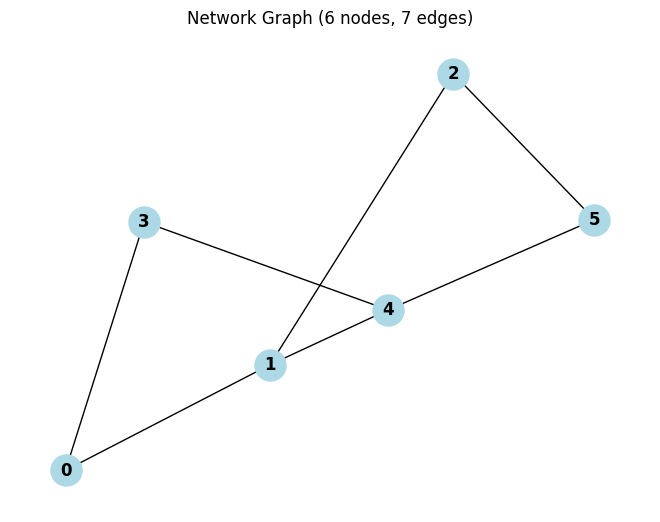

In [3]:
# =============================================================================
# LOAD NETWORK GRAPH
# =============================================================================

with open(NETWORK_GRAPH_PATH, 'rb') as f:
    network_graph = pickle.load(f)

num_nodes = network_graph.number_of_nodes()
num_edges = network_graph.number_of_edges()

print(f"Network: {num_nodes} nodes, {num_edges} edges")
print(f"Nodes: {list(network_graph.nodes())}")
print(f"Edges: {list(network_graph.edges())}")

nx.draw(network_graph, with_labels=True, node_color='lightblue',
        node_size=500, font_size=12, font_weight='bold')
plt.title(f'Network Graph ({num_nodes} nodes, {num_edges} edges)')
plt.show()

In [4]:
# =============================================================================
# GENERATE QUBIT MAPPING
# =============================================================================

node_qubits, path_qubits, total_qubits = Code513.generate_qubit_mapping(num_nodes)

print(f"Qubit mapping for {num_nodes}-node network:")
print(f"  Qubits per node: {Code513.QUBITS_PER_NODE} (5 data + 4 ancilla)")
print(f"  Total qubits: {total_qubits}")
print(f"  Node qubits: {len(node_qubits)} nodes")
print(f"  Path qubits: {len(path_qubits)} edges")

# Verify all graph edges have path qubits
for edge in network_graph.edges():
    edge_key = tuple(sorted(edge))
    assert edge_key in path_qubits, f"Missing path qubits for edge {edge_key}"
print("\nAll graph edges have path qubits assigned.")

Qubit mapping for 6-node network:
  Qubits per node: 9 (5 data + 4 ancilla)
  Total qubits: 69
  Node qubits: 6 nodes
  Path qubits: 15 edges

All graph edges have path qubits assigned.


In [5]:
# =============================================================================
# BUILD NOISY SIMULATOR
# =============================================================================

t0 = time.time()
noisy_sim, basis_gates, fake_backend = build_simulator(
    noise_type=NOISE_TYPE,
    num_circuit_qubits=total_qubits,
    error_rate_2q=ERROR_RATE_2Q,
    backend=BACKEND,
)
print(f"Simulator built in {time.time() - t0:.1f}s")
print(f"  Backend: {fake_backend.name} ({fake_backend.num_qubits} physical qubits)")
print(f"  Basis gates: {basis_gates}")
print(f"  Circuit qubits: {total_qubits}")

Simulator built in 0.2s
  Backend: fake_fez (156 physical qubits)
  Basis gates: ['cz', 'id', 'rz', 'sx', 'x']
  Circuit qubits: 69


## Syndrome-Based Pauli Error Extraction

The [[5,1,3]] code is a **perfect code** — every non-zero syndrome uniquely identifies a single-qubit Pauli error:

| Error | q0 | q1 | q2 | q3 | q4 |
|-------|----|----|----|----|----|
| X     |  8 |  1 |  3 |  6 | 12 |
| Y     | 13 | 11 |  7 | 15 | 14 |
| Z     |  5 | 10 |  4 |  9 |  2 |

Under i.i.d. Pauli noise with rates $(p_I, p_x, p_y, p_z)$ on each qubit:

- $P_0 \approx p_I^5$  (no error on any qubit)
- $P_X = \sum_{s \in \text{X-group}} P(s) \approx 5 \cdot p_x \cdot p_I^4$
- $P_Y = \sum_{s \in \text{Y-group}} P(s) \approx 5 \cdot p_y \cdot p_I^4$
- $P_Z = \sum_{s \in \text{Z-group}} P(s) \approx 5 \cdot p_z \cdot p_I^4$

Solving:

$$p_x = \frac{P_X}{5 \cdot P_0^{4/5}}, \quad p_y = \frac{P_Y}{5 \cdot P_0^{4/5}}, \quad p_z = \frac{P_Z}{5 \cdot P_0^{4/5}}$$

The syndrome is independent of the logical state (stabilizers commute with logical operators), so we can combine shots from both $|0\rangle_L$ and $|1\rangle_L$ for better statistics.

In [6]:
# =============================================================================
# [[5,1,3]] SYNDROME GROUPS
# =============================================================================

# Build syndrome lookup table from stabilizers
STABILIZERS = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

def _anticommutes(p1: str, p2: str) -> bool:
    """Check if two single-qubit Paulis anticommute."""
    if p1 == 'I' or p2 == 'I':
        return False
    return p1 != p2

SYNDROME_TABLE = {}
for error in ['I', 'X', 'Y', 'Z']:
    for qubit in range(5):
        syndrome = 0
        if error != 'I':
            for stab_idx, stabilizer in enumerate(STABILIZERS):
                if _anticommutes(error, stabilizer[qubit]):
                    syndrome |= (1 << stab_idx)
        SYNDROME_TABLE[(error, qubit)] = syndrome

# Extract the three syndrome groups
X_GROUP = {SYNDROME_TABLE[('X', q)] for q in range(5)}
Y_GROUP = {SYNDROME_TABLE[('Y', q)] for q in range(5)}
Z_GROUP = {SYNDROME_TABLE[('Z', q)] for q in range(5)}

print("Syndrome groups (derived from stabilizers):")
print(f"  X-error syndromes: {sorted(X_GROUP)}")
print(f"  Y-error syndromes: {sorted(Y_GROUP)}")
print(f"  Z-error syndromes: {sorted(Z_GROUP)}")

# Verify: all 15 non-zero syndromes are covered (perfect code property)
all_syndromes = X_GROUP | Y_GROUP | Z_GROUP
assert all_syndromes == set(range(1, 16)), "Not all syndromes covered!"
assert len(X_GROUP) == len(Y_GROUP) == len(Z_GROUP) == 5
print("\nVerified: all 15 non-zero syndromes partitioned into 3 groups of 5.")

Syndrome groups (derived from stabilizers):
  X-error syndromes: [1, 3, 6, 8, 12]
  Y-error syndromes: [7, 11, 13, 14, 15]
  Z-error syndromes: [2, 4, 5, 9, 10]

Verified: all 15 non-zero syndromes partitioned into 3 groups of 5.


In [7]:
# =============================================================================
# PAULI RATE EXTRACTION FUNCTION
# =============================================================================

def extract_pauli_rates(histogram: np.ndarray) -> Dict[str, float]:
    """
    Extract per-qubit Pauli error rates from a [[5,1,3]] syndrome histogram.
    
    Uses the first-order approximation (valid when error rates are small):
        P_0  ~= p_I^5
        P_X  ~= 5 * px * p_I^4
        P_Y  ~= 5 * py * p_I^4
        P_Z  ~= 5 * pz * p_I^4
    
    Args:
        histogram: 16-element array of syndrome counts
    
    Returns:
        dict with 'px', 'py', 'pz', 'p_total', 'P_0', 'P_X', 'P_Y', 'P_Z'
    """
    probs = histogram / np.sum(histogram)
    
    # Step 1: Group syndrome probabilities
    P_0 = probs[0]
    P_X = sum(probs[s] for s in X_GROUP)
    P_Y = sum(probs[s] for s in Y_GROUP)
    P_Z = sum(probs[s] for s in Z_GROUP)
    
    # Step 2: Extract per-qubit error rates (first-order approximation)
    # Guard against P_0 = 0 (completely noisy channel)
    if P_0 <= 0:
        return {'px': np.nan, 'py': np.nan, 'pz': np.nan, 'p_total': np.nan,
                'P_0': P_0, 'P_X': P_X, 'P_Y': P_Y, 'P_Z': P_Z}
    
    denominator = 5.0 * P_0 ** (4.0 / 5.0)
    
    px = P_X / denominator
    py = P_Y / denominator
    pz = P_Z / denominator
    p_total = 1.0 - P_0 ** (1.0 / 5.0)
    
    return {
        'px': px, 'py': py, 'pz': pz,
        'p_total': p_total,
        'P_0': P_0, 'P_X': P_X, 'P_Y': P_Y, 'P_Z': P_Z,
    }

print("Extraction function defined.")

Extraction function defined.


## Data Generation

For each edge in the network graph:
1. Build encode-SWAP-syndrome circuit for logical |0> and |1>
2. Transpile and run on the noisy simulator
3. Combine histograms from both initial states (2x the statistics)
4. Extract per-qubit (px, py, pz) from the combined histogram

In [8]:
# =============================================================================
# RUN CIRCUITS FOR ALL EDGES
# =============================================================================

edges = list(network_graph.edges())
edge_results = {}  # {edge: {'histogram_0': ..., 'histogram_1': ..., 'combined': ...}}

print("=" * 70)
print("[[5,1,3]] SYNDROME-BASED GROUND TRUTH EXTRACTION")
print("=" * 70)
print(f"Edges to process: {len(edges)}")
print(f"Shots per circuit: {NUM_SHOTS} (x2 for |0> and |1>)")
print("=" * 70)

t_total = time.time()

for idx, edge in enumerate(edges):
    src, snk = edge
    path = [src, snk]
    print(f"\n[{idx+1}/{len(edges)}] Edge {edge}  (path: {path})")
    
    histograms = {}
    for init_state in ['0', '1']:
        t0 = time.time()
        
        # Build circuit: encode at source, SWAP to sink, measure syndrome
        circuit = build_swap_circuit(
            Code513, node_qubits, path_qubits, total_qubits,
            path, initial_state=init_state,
        )
        
        # Transpile to basis gates
        transpiled = transpile(
            circuit, basis_gates=basis_gates,
            optimization_level=OPTIMIZATION_LEVEL,
        )
        
        # Run on noisy simulator
        result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
        counts = result.get_counts()
        
        # Build 16-bin histogram
        hist = build_histogram(counts, num_bits=4, num_syndromes=16)
        histograms[init_state] = hist
        
        elapsed = time.time() - t0
        p0 = hist[0] / hist.sum()
        print(f"  |{init_state}>: P(0000)={p0:.4f}  depth={transpiled.depth()}  ({elapsed:.1f}s)")
    
    # Combine histograms from |0> and |1>
    combined = histograms['0'] + histograms['1']
    
    edge_results[edge] = {
        'histogram_0': histograms['0'],
        'histogram_1': histograms['1'],
        'combined': combined,
    }

elapsed_total = time.time() - t_total
print(f"\n{'=' * 70}")
print(f"Done: {len(edges)} edges in {elapsed_total:.1f}s")
print(f"{'=' * 70}")

[[5,1,3]] SYNDROME-BASED GROUND TRUTH EXTRACTION
Edges to process: 7
Shots per circuit: 8192 (x2 for |0> and |1>)

[1/7] Edge (0, 1)  (path: [0, 1])
  |0>: P(0000)=0.6466  depth=106  (3.2s)
  |1>: P(0000)=0.6509  depth=106  (3.5s)

[2/7] Edge (0, 3)  (path: [0, 3])
  |0>: P(0000)=0.6440  depth=106  (3.5s)
  |1>: P(0000)=0.6423  depth=106  (3.5s)

[3/7] Edge (1, 2)  (path: [1, 2])
  |0>: P(0000)=0.6438  depth=106  (3.3s)
  |1>: P(0000)=0.6436  depth=106  (3.1s)

[4/7] Edge (1, 4)  (path: [1, 4])
  |0>: P(0000)=0.6545  depth=106  (3.4s)
  |1>: P(0000)=0.6510  depth=106  (3.2s)

[5/7] Edge (2, 5)  (path: [2, 5])
  |0>: P(0000)=0.6436  depth=106  (3.2s)
  |1>: P(0000)=0.6448  depth=106  (3.4s)

[6/7] Edge (3, 4)  (path: [3, 4])
  |0>: P(0000)=0.6534  depth=106  (3.4s)
  |1>: P(0000)=0.6644  depth=106  (3.4s)

[7/7] Edge (4, 5)  (path: [4, 5])
  |0>: P(0000)=0.6538  depth=106  (3.2s)
  |1>: P(0000)=0.6521  depth=106  (3.4s)

Done: 7 edges in 46.6s


In [9]:
# =============================================================================
# EXTRACT PAULI RATES FOR EACH EDGE
# =============================================================================

ground_truth_syndrome = {}  # {edge: [px, py, pz]} — the final output
results_table = []          # For display

print("=" * 70)
print("PER-EDGE PAULI ERROR RATES (from [[5,1,3]] syndrome)")
print("=" * 70)

for edge in edges:
    combined = edge_results[edge]['combined']
    rates = extract_pauli_rates(combined)
    
    px, py, pz = rates['px'], rates['py'], rates['pz']
    ground_truth_syndrome[edge] = [px, py, pz]
    
    results_table.append({
        'Edge': str(edge),
        'px': px,
        'py': py,
        'pz': pz,
        'p_total': rates['p_total'],
        'P(0000)': rates['P_0'],
        'P_X': rates['P_X'],
        'P_Y': rates['P_Y'],
        'P_Z': rates['P_Z'],
    })
    
    print(f"  {edge}: px={px:.6f}  py={py:.6f}  pz={pz:.6f}  total={rates['p_total']:.6f}")

print(f"\n{'=' * 70}")

PER-EDGE PAULI ERROR RATES (from [[5,1,3]] syndrome)
  (0, 1): px=0.035824  py=0.028473  pz=0.035013  total=0.082905
  (0, 3): px=0.036888  py=0.028896  pz=0.035794  total=0.084480
  (1, 2): px=0.035598  py=0.029972  pz=0.035807  total=0.084341
  (1, 4): px=0.034737  py=0.028298  pz=0.034652  total=0.081769
  (2, 5): px=0.035455  py=0.029902  pz=0.035820  total=0.084203
  (3, 4): px=0.034187  py=0.026569  pz=0.034477  total=0.080041
  (4, 5): px=0.035657  py=0.027124  pz=0.034833  total=0.081717



In [10]:
# =============================================================================
# RESULTS TABLE
# =============================================================================

df = pd.DataFrame(results_table)

styled = (df
    .style
    .format({
        'px': '{:.6f}', 'py': '{:.6f}', 'pz': '{:.6f}',
        'p_total': '{:.6f}', 'P(0000)': '{:.4f}',
        'P_X': '{:.4f}', 'P_Y': '{:.4f}', 'P_Z': '{:.4f}',
    })
    .set_caption('Per-Edge Pauli Error Rates from [[5,1,3]] Syndrome')
    .background_gradient(subset=['p_total'], cmap='YlOrRd', vmin=0)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]},
    ])
)

display(styled)

,Edge,px,py,pz,p_total,P(0000),P_X,P_Y,P_Z
0,"(0, 1)",0.035824,0.028473,0.035013,0.082905,0.6487,0.1267,0.1007,0.1238
1,"(0, 3)",0.036888,0.028896,0.035794,0.084480,0.6432,0.1296,0.1015,0.1257
2,"(1, 2)",0.035598,0.029972,0.035807,0.084341,0.6437,0.1251,0.1053,0.1259
3,"(1, 4)",0.034737,0.028298,0.034652,0.081769,0.6528,0.1235,0.1006,0.1232
4,"(2, 5)",0.035455,0.029902,0.035820,0.084203,0.6442,0.1247,0.1052,0.1260
5,"(3, 4)",0.034187,0.026569,0.034477,0.080041,0.6589,0.1224,0.0952,0.1235
6,"(4, 5)",0.035657,0.027124,0.034833,0.081717,0.6530,0.1268,0.0964,0.1238


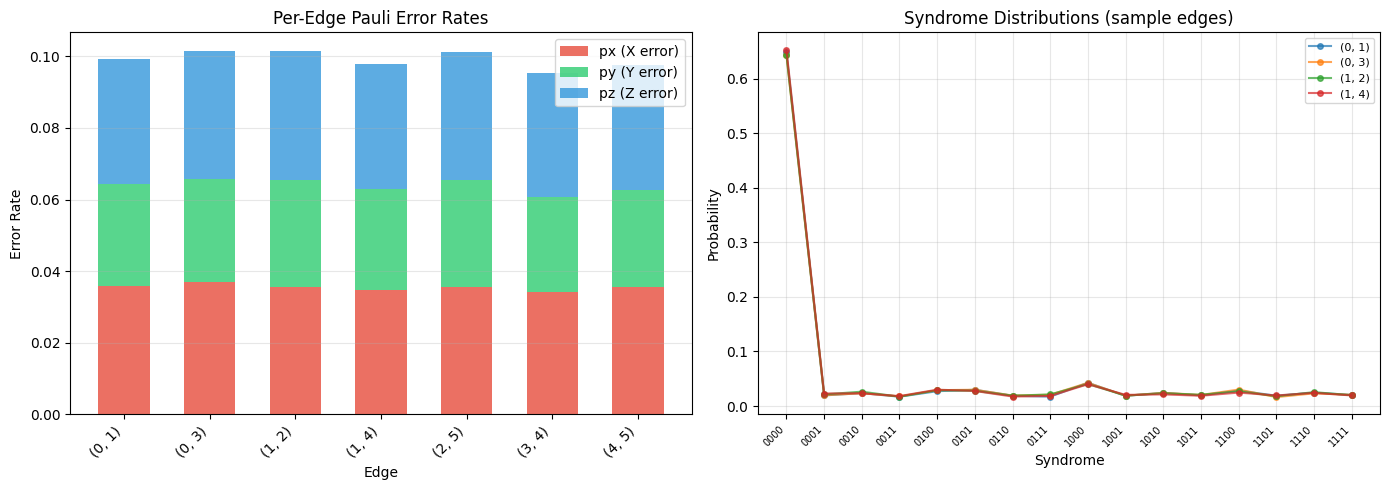

In [11]:
# =============================================================================
# VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stacked bar chart of px, py, pz per edge
ax1 = axes[0]
edge_labels = [str(e) for e in edges]
x = np.arange(len(edges))
width = 0.6

px_vals = [ground_truth_syndrome[e][0] for e in edges]
py_vals = [ground_truth_syndrome[e][1] for e in edges]
pz_vals = [ground_truth_syndrome[e][2] for e in edges]

ax1.bar(x, px_vals, width, label='px (X error)', color='#e74c3c', alpha=0.8)
ax1.bar(x, py_vals, width, bottom=px_vals, label='py (Y error)', color='#2ecc71', alpha=0.8)
ax1.bar(x, pz_vals, width, bottom=np.array(px_vals) + np.array(py_vals),
        label='pz (Z error)', color='#3498db', alpha=0.8)

ax1.set_xlabel('Edge')
ax1.set_ylabel('Error Rate')
ax1.set_title('Per-Edge Pauli Error Rates')
ax1.set_xticks(x)
ax1.set_xticklabels(edge_labels, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Syndrome histograms for first 4 edges
ax2 = axes[1]
SYNDROME_LABELS = [format(i, '04b') for i in range(16)]

for i, edge in enumerate(edges[:4]):
    combined = edge_results[edge]['combined']
    probs = combined / combined.sum()
    ax2.plot(range(16), probs, 'o-', alpha=0.7, markersize=4, label=str(edge))

ax2.set_xlabel('Syndrome')
ax2.set_ylabel('Probability')
ax2.set_title('Syndrome Distributions (sample edges)')
ax2.set_xticks(range(16))
ax2.set_xticklabels(SYNDROME_LABELS, rotation=45, ha='right', fontsize=7)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# CONSISTENCY CHECK: |0> vs |1> HISTOGRAMS
# =============================================================================
# The syndrome should be identical for |0>_L and |1>_L since stabilizers
# commute with logical operators. Any difference is purely statistical noise.

print("Consistency check: |0> vs |1> syndrome histograms")
print("-" * 50)

for edge in edges:
    h0 = edge_results[edge]['histogram_0']
    h1 = edge_results[edge]['histogram_1']
    p0 = h0 / h0.sum()
    p1 = h1 / h1.sum()
    tvd = 0.5 * np.sum(np.abs(p0 - p1))
    print(f"  {edge}: TVD(|0>, |1>) = {tvd:.4f}")

print("\n(TVD should be small — differences are just shot noise)")

Consistency check: |0> vs |1> syndrome histograms
--------------------------------------------------
  (0, 1): TVD(|0>, |1>) = 0.0142
  (0, 3): TVD(|0>, |1>) = 0.0171
  (1, 2): TVD(|0>, |1>) = 0.0154
  (1, 4): TVD(|0>, |1>) = 0.0178
  (2, 5): TVD(|0>, |1>) = 0.0109
  (3, 4): TVD(|0>, |1>) = 0.0217
  (4, 5): TVD(|0>, |1>) = 0.0154

(TVD should be small — differences are just shot noise)


## Save Results

In [13]:
# =============================================================================
# SAVE TO PICKLE
# =============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(OUTPUT_DIR, 'ground_truth_from_syndrome.pkl')
with open(output_path, 'wb') as f:
    pickle.dump(ground_truth_syndrome, f)

# Also save the graph for reference
graph_path = os.path.join(OUTPUT_DIR, 'graph.pkl')
with open(graph_path, 'wb') as f:
    pickle.dump(network_graph, f)

# Verify by loading back
with open(output_path, 'rb') as f:
    loaded = pickle.load(f)

print(f"Saved to: {output_path}")
print(f"Format: {{(edge): [px, py, pz]}}")
print(f"\nVerification — loaded {len(loaded)} edges:")
for edge, rates in loaded.items():
    print(f"  {edge}: px={rates[0]:.6f}, py={rates[1]:.6f}, pz={rates[2]:.6f}")

Saved to: ../pickle_files/syndrome_ground_truth_513/ground_truth_from_syndrome.pkl
Format: {(edge): [px, py, pz]}

Verification — loaded 7 edges:
  (0, 1): px=0.035824, py=0.028473, pz=0.035013
  (0, 3): px=0.036888, py=0.028896, pz=0.035794
  (1, 2): px=0.035598, py=0.029972, pz=0.035807
  (1, 4): px=0.034737, py=0.028298, pz=0.034652
  (2, 5): px=0.035455, py=0.029902, pz=0.035820
  (3, 4): px=0.034187, py=0.026569, pz=0.034477
  (4, 5): px=0.035657, py=0.027124, pz=0.034833


In [14]:
# =============================================================================
# SUMMARY
# =============================================================================

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Network: {num_nodes} nodes, {num_edges} edges")
print(f"  Backend: {BACKEND} ({NOISE_TYPE}, 2Q rate={ERROR_RATE_2Q})")
print(f"  Shots per edge: {NUM_SHOTS * 2} ({NUM_SHOTS} x 2 initial states)")
print(f"  Output: {output_path}")
print()

totals = [sum(rates) for rates in ground_truth_syndrome.values()]
print(f"  Mean total error rate:  {np.mean(totals):.6f}")
print(f"  Min total error rate:   {np.min(totals):.6f}")
print(f"  Max total error rate:   {np.max(totals):.6f}")
print("=" * 60)

SUMMARY
  Network: 6 nodes, 7 edges
  Backend: heron_r2 (depolarizing, 2Q rate=0.01)
  Shots per edge: 16384 (8192 x 2 initial states)
  Output: ../pickle_files/syndrome_ground_truth_513/ground_truth_from_syndrome.pkl

  Mean total error rate:  0.099140
  Min total error rate:   0.095234
  Max total error rate:   0.101578
